<a href="https://colab.research.google.com/github/sohanpatil009/Code_crafter/blob/main/dl_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import platform
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

print('Python version:', platform.python_version())
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Python version: 3.13.15
PyTorch version: 2.11.0+cu128
CUDA available: True


In [3]:
# Hyperparameters
CONFIG = {
    "batch_size": 128,
    "epochs_stage1": 5,   # Shorter epochs for the baseline evaluation model
    "epochs_final": 10,   # Epochs for final comparison models
    "learning_rate": 0.001,
    "num_classes": 10
}

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Base transform (No augmentation, just normalization)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print("Downloading CIFAR-10 dataset...")
trainset_base = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=base_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=base_transform)

trainloader_base = DataLoader(trainset_base, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

100%|██████████| 170M/170M [38:33<00:00, 73.7kB/s]


In [5]:
def get_model():
    """Returns a ResNet18 adapted for CIFAR-10."""
    model = torchvision.models.resnet18(pretrained=False)
    # Adapt the first conv layer for 32x32 images
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, CONFIG["num_classes"])
    return model.to(device)

def train_model(model, trainloader, epochs, title="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

    model.train()
    print(f"--- Training {title} ---")
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(trainloader):.4f}")
    return model

def evaluate_model(model, testloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    return acc, p, r, f1, all_labels, all_preds

In [6]:
baseline_model = get_model()
baseline_model = train_model(baseline_model, trainloader_base, epochs=CONFIG["epochs_stage1"], title="Stage 1 (No DA)")

base_acc, _, _, _, _, _ = evaluate_model(baseline_model, testloader)
print(f"Stage 1 Baseline Accuracy: {base_acc*100:.2f}%")

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


--- Training Stage 1 (No DA) ---
Epoch 1/5 | Loss: 1.1879
Epoch 2/5 | Loss: 0.7077
Epoch 3/5 | Loss: 0.5267
Epoch 4/5 | Loss: 0.3956
Epoch 5/5 | Loss: 0.2921
Stage 1 Baseline Accuracy: 77.89%


In [7]:
import torch.nn.functional as F

# Candidate transformations
candidate_transforms = {
    "h_flip": transforms.RandomHorizontalFlip(p=1.0),
    "rotate": transforms.RandomRotation(degrees=(30, 30)),
    "color": transforms.ColorJitter(brightness=0.4, contrast=0.4)
}

# Dictionary to hold the selected policy for each class
class_policies = {i: [] for i in range(CONFIG["num_classes"])}

baseline_model.eval()
num_samples_to_test = 50

print("Evaluating transformations per class...")
with torch.no_grad():
    for c in range(CONFIG["num_classes"]):
        # Get samples for class 'c'
        class_indices = [i for i, label in enumerate(trainset_base.targets) if label == c][:num_samples_to_test]

        for t_name, trans in candidate_transforms.items():
            conf_drops = []
            for idx in class_indices:
                img_tensor, label = trainset_base[idx]
                img_batch = img_tensor.unsqueeze(0).to(device)

                # Original confidence
                orig_out = baseline_model(img_batch)
                orig_conf = F.softmax(orig_out, dim=1)[0][c].item()

                # Convert back to PIL, transform, and back to tensor
                img_pil = transforms.ToPILImage()(img_tensor)
                aug_img = trans(img_pil)
                aug_tensor = transforms.ToTensor()(aug_img)
                aug_tensor = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))(aug_tensor)

                # Augmented confidence
                aug_batch = aug_tensor.unsqueeze(0).to(device)
                aug_out = baseline_model(aug_batch)
                aug_conf = F.softmax(aug_out, dim=1)[0][c].item()

                conf_drops.append(orig_conf - aug_conf)

            # If the average confidence drop is small, the transformation is safe!
            avg_drop = np.mean(conf_drops)
            if avg_drop < 0.15:  # Tolerance threshold
                class_policies[c].append(t_name)

print("\nDerived Class-Adaptive Policies:")
for c, pol in class_policies.items():
    print(f"{classes[c]:10s} (Class {c}): {pol if pol else ['None']}")

Evaluating transformations per class...

Derived Class-Adaptive Policies:
plane      (Class 0): ['None']
car        (Class 1): ['None']
bird       (Class 2): ['None']
cat        (Class 3): ['None']
deer       (Class 4): ['None']
dog        (Class 5): ['None']
frog       (Class 6): ['None']
horse      (Class 7): ['None']
ship       (Class 8): ['None']
truck      (Class 9): ['None']


In [8]:
class UniformDataset(Dataset):
    def __init__(self, original_dataset):
        self.dataset = original_dataset
        self.uniform_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        ])
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img_pil = transforms.ToPILImage()(self.dataset[idx][0])
        return self.uniform_transform(img_pil), self.dataset[idx][1]

class AdaptiveDataset(Dataset):
    def __init__(self, original_dataset, policies):
        self.dataset = original_dataset
        self.policies = policies
        self.normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img_tensor, label = self.dataset[idx]
        img_pil = transforms.ToPILImage()(img_tensor)

        # Apply only the safe transforms for this specific class
        active_policy = self.policies[label]
        if "h_flip" in active_policy and random.random() > 0.5:
            img_pil = candidate_transforms["h_flip"](img_pil)
        if "rotate" in active_policy and random.random() > 0.5:
            img_pil = candidate_transforms["rotate"](img_pil)
        if "color" in active_policy and random.random() > 0.5:
            img_pil = candidate_transforms["color"](img_pil)

        final_tensor = transforms.ToTensor()(img_pil)
        return self.normalize(final_tensor), label

# Prepare DataLoaders
trainset_uniform = UniformDataset(trainset_base)
trainset_adaptive = AdaptiveDataset(trainset_base, class_policies)

loader_uniform = DataLoader(trainset_uniform, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
loader_adaptive = DataLoader(trainset_adaptive, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)

# Train Uniform Model
model_uniform = get_model()
model_uniform = train_model(model_uniform, loader_uniform, epochs=CONFIG["epochs_final"], title="Uniform DA Model")

# Train Adaptive Model
model_adaptive = get_model()
model_adaptive = train_model(model_adaptive, loader_adaptive, epochs=CONFIG["epochs_final"], title="Class-Adaptive DA Model")

--- Training Uniform DA Model ---


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/10 | Loss: 1.8261
Epoch 2/10 | Loss: 1.5309
Epoch 3/10 | Loss: 1.3860
Epoch 4/10 | Loss: 1.2568
Epoch 5/10 | Loss: 1.1593
Epoch 6/10 | Loss: 1.0754
Epoch 7/10 | Loss: 1.0164
Epoch 8/10 | Loss: 0.9505
Epoch 9/10 | Loss: 0.8998
Epoch 10/10 | Loss: 0.8572
--- Training Class-Adaptive DA Model ---
Epoch 1/10 | Loss: 1.7255
Epoch 2/10 | Loss: 1.3751
Epoch 3/10 | Loss: 1.1790
Epoch 4/10 | Loss: 1.0076
Epoch 5/10 | Loss: 0.8309
Epoch 6/10 | Loss: 0.6429
Epoch 7/10 | Loss: 0.4479
Epoch 8/10 | Loss: 0.2908
Epoch 9/10 | Loss: 0.1826
Epoch 10/10 | Loss: 0.1427



--- Final Performance Comparison ---
| Metric          |   Without DA (Baseline) |   Uniform DA |   Class-Adaptive DA |
|:----------------|------------------------:|-------------:|--------------------:|
| Accuracy        |                  0.7789 |       0.3109 |              0.1959 |
| Macro Precision |                  0.806  |       0.4917 |              0.434  |
| Macro Recall    |                  0.7789 |       0.3109 |              0.1959 |
| Macro F1        |                  0.7778 |       0.2766 |              0.1518 |


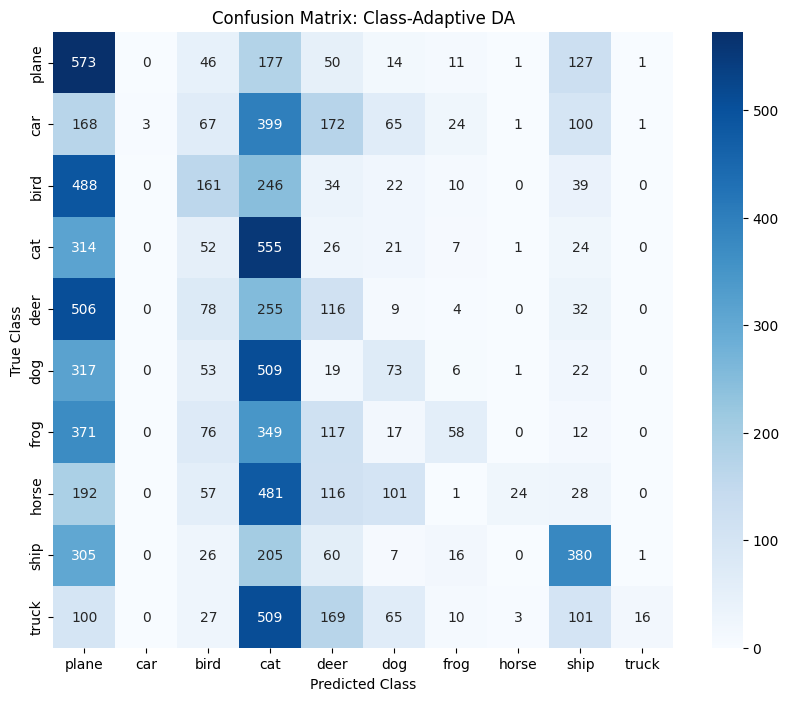

In [9]:
import pandas as pd

# Re-evaluate Baseline for direct comparison
acc_b, p_b, r_b, f1_b, _, _ = evaluate_model(baseline_model, testloader)
acc_u, p_u, r_u, f1_u, _, _ = evaluate_model(model_uniform, testloader)
acc_a, p_a, r_a, f1_a, labels_true, preds_a = evaluate_model(model_adaptive, testloader)

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    "Without DA (Baseline)": [acc_b, p_b, r_b, f1_b],
    "Uniform DA": [acc_u, p_u, r_u, f1_u],
    "Class-Adaptive DA": [acc_a, p_a, r_a, f1_a]
})

print("\n--- Final Performance Comparison ---")
print(results_df.round(4).to_markdown(index=False))

# Confusion Matrix for Class-Adaptive Model
cm = confusion_matrix(labels_true, preds_a)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: Class-Adaptive DA')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()